# AED — X (Twitter): léxico xenófobo y métricas

Análisis exploratorio del corpus de **X** recolectado por **búsqueda dirigida**
(Práctica 6). A diferencia de YouTube (comentarios en bloque + marcado posterior),
X se recolecta consultando los patrones xenófobos exactos (`Brasil monos`, `sudacas`,
`France is not Africa`…), aprovechando su buscador. Por eso el corpus es ~96 %
`dirigida` **por diseño**: es la aguja, no el pajar. Es la misma decisión metodológica
del proyecto: *adaptar la recolección al modelo de acceso de cada red*.

> **Marcado = mismo código que el extractor** (`extractor_mundial.lexico`), idéntico a
> YouTube: substring en minúsculas contra `config/lexico.txt`, con límite de palabra
> para los términos `# exacto` y descarte de menciones `@usuario`. Cada término lleva
> su **eje** temático (anti-negro/simiesco, anti-mexicano/migrante, sudamericano/
> regional, colonial/autenticidad, anti-asiático).

> A diferencia de YouTube, **X declara el idioma** de cada tweet → el campo `idioma`
> está poblado, y podemos ver el carácter **multiidioma** del odio.

In [1]:
import json, re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})
# Paleta apta para daltonismo: azul para magnitud; naranja para resaltar.
AZUL, NARANJA = "#4E79A7", "#F28E2B"
pd.set_option("display.max_colwidth", 90)

In [2]:
df = pd.read_csv("data/x.csv")
print(f"{len(df):,} tweets cargados")
df.head(3)

3,150 tweets cargados


,id,red,estrategia,criterio_busqueda,texto,idioma,autor,fecha_publicacion,url,metricas,fecha_extraccion
0,2077077332045517051,x,amplia,#WorldCup2026,今晚 5X，上線 LBank Predict。\n\n 法國 vs 西班牙 \n世界盃決賽席位，今晚一戰定奪。\n\n關注市場走勢：\n\nhttps://\nlbank....,zh,@LBankchinese,2026-07-14T17:06:40.000Z,https://x.com/LBankchinese/status/2077077332045517051,"{""likes"": 0, ""reposts"": 0, ""respuestas"": 0}",2026-07-14T17:07:04.263887+00:00
1,2077077305277784524,x,amplia,#WorldCup2026,"World Cup semifinal Tuesday: Argentina-England in Atlanta, France-Spain in Dallas. Eve...",en,@tonsofpetefun,2026-07-14T17:06:34.000Z,https://x.com/tonsofpetefun/status/2077077305277784524,"{""likes"": 0, ""reposts"": 0, ""respuestas"": 0}",2026-07-14T17:07:04.284949+00:00
2,2077077291092295698,x,amplia,#WorldCup2026,MATCH DAY! France vs Spain\nA place in the FIFA World Cup Final is on the line.\nWho b...,en,@Official_UpDown,2026-07-14T17:06:31.000Z,https://x.com/Official_UpDown/status/2077077291092295698,"{""likes"": 0, ""reposts"": 0, ""respuestas"": 0}",2026-07-14T17:07:04.308636+00:00


## 1. Preparación: métricas y marcado del léxico

Reconstruimos por tweet los **términos** del léxico disparados y sus **ejes**, con el
mismo código del extractor. X trae tres métricas: `likes`, `reposts` (amplificación) y
`respuestas`.

In [3]:
def parse_num(x):
    """Convierte likes/reposts a int (X ya los da como número)."""
    s = str(x).strip().replace(",", "")
    if not s or s.lower() == "nan":
        return 0
    mult = 1
    if s[-1:].lower() == "k":
        mult, s = 1_000, s[:-1]
    elif s[-1:].lower() == "m":
        mult, s = 1_000_000, s[:-1]
    try:
        return int(float(s) * mult)
    except ValueError:
        return 0

m = df["metricas"].apply(json.loads)
df["likes"] = m.apply(lambda d: parse_num(d.get("likes")))
df["reposts"] = m.apply(lambda d: parse_num(d.get("reposts")))
df["respuestas"] = m.apply(lambda d: parse_num(d.get("respuestas")))

# Marcado con el MISMO código del extractor (fuente única de verdad).
from extractor_mundial.lexico import cargar as cargar_lexico

LEX = cargar_lexico(Path("config/lexico.txt"))
_disparos = df["texto"].apply(LEX.disparos)
df["terminos"] = _disparos.apply(lambda ds: [e.termino for e in ds])
df["ejes"] = _disparos.apply(lambda ds: sorted({e.eje for e in ds}))

# Dos señales distintas, ambas útiles:
#  - dirigida (recolección): el tweet vino de una BÚSQUEDA dirigida (evento × léxico).
#  - con_lexico: su TEXTO visible contiene literalmente un término del léxico.
# X busca sobre el tweet completo/hilo, así que no todo dirigido muestra el término.
df["dirigida"] = df["estrategia"] == "dirigida"
df["con_lexico"] = df["terminos"].str.len() > 0

n_ejes = len({e.eje for e in LEX.entradas})
print(f"léxico activo: {len(LEX.entradas)} términos en {n_ejes} ejes")
print(f"recolectados por búsqueda 'dirigida': {df['dirigida'].sum()}")
print(f"con término del léxico en el texto:   {df['con_lexico'].sum()} "
      f"({100*df['con_lexico'].mean():.0f}% del total)")

léxico activo: 104 términos en 6 ejes
recolectados por búsqueda 'dirigida': 3031
con término del léxico en el texto:   2203 (70% del total)


## 2. Panorama general

El corpus es `dirigida` casi entero **por diseño** (búsqueda dirigida). Se reportan dos
señales: los tweets **recolectados** por búsqueda dirigida y, de ésos, cuántos traen el
término del léxico **literal en el texto** (el resto matchearon la query por hilo/
contexto).

In [4]:
pd.Series({
    "tweets": len(df),
    "autores únicos": df["autor"].nunique(),
    "idiomas": df["idioma"].nunique(),
    "queries (criterios)": df["criterio_busqueda"].nunique(),
    "dirigida (recolección)": int(df["dirigida"].sum()),
    "amplia (hashtags)": int((~df["dirigida"]).sum()),
    "con término en el texto": int(df["con_lexico"].sum()),
    "% con término": round(100 * df["con_lexico"].mean(), 1),
}, name="valor").to_frame()

,valor
tweets,3150.0
autores únicos,2687.0
idiomas,22.0
queries (criterios),27.0
dirigida (recolección),3031.0
amplia (hashtags),119.0
con término en el texto,2203.0
% con término,69.9


## 3. Idioma del odio (X sí lo declara)

Ventaja de X sobre YouTube: cada tweet trae su idioma. El odio es **multiidioma** —
español e inglés dominan, con cola de francés/portugués/japonés/árabe.

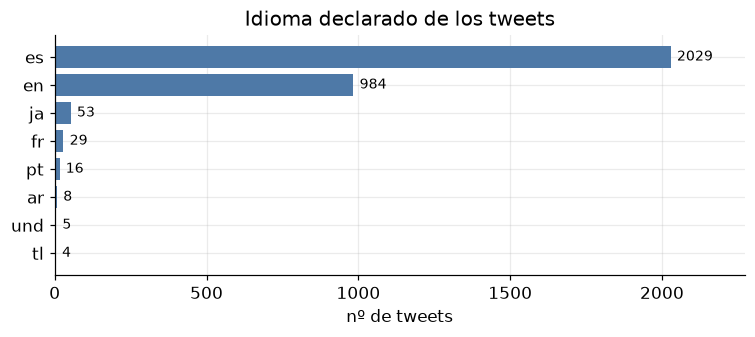

,tweets
idioma,
es,2029
en,984
ja,53
fr,29
pt,16
ar,8
und,5
tl,4


In [5]:
idi = df["idioma"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(idi.index[::-1], idi.values[::-1], color=AZUL)
for y, v in enumerate(idi.values[::-1]):
    ax.text(v + max(idi.values) * 0.01, y, str(v), va="center", fontsize=9)
ax.set_title("Idioma declarado de los tweets")
ax.set_xlabel("nº de tweets")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()
idi.to_frame("tweets")

## 4. El léxico xenófobo en los tweets

¿Qué términos aparecen y con qué frecuencia?

In [6]:
freq = Counter()
for terms in df["terminos"]:
    freq.update(terms)

tab = pd.DataFrame(freq.most_common(), columns=["término", "tweets"])
print(f"{len(freq)} términos distintos del léxico aparecen (de {len(LEX.entradas)} activos)")
tab.head(20)

30 términos distintos del léxico aparecen (de 104 activos)


,término,tweets
0,monos,917
1,sudaca,495
2,frijolero,379
3,sudacas,213
4,saltamuros,189
5,frijoleros,183
6,monkey,176
7,beaner,112
8,simio,36
9,simios,25


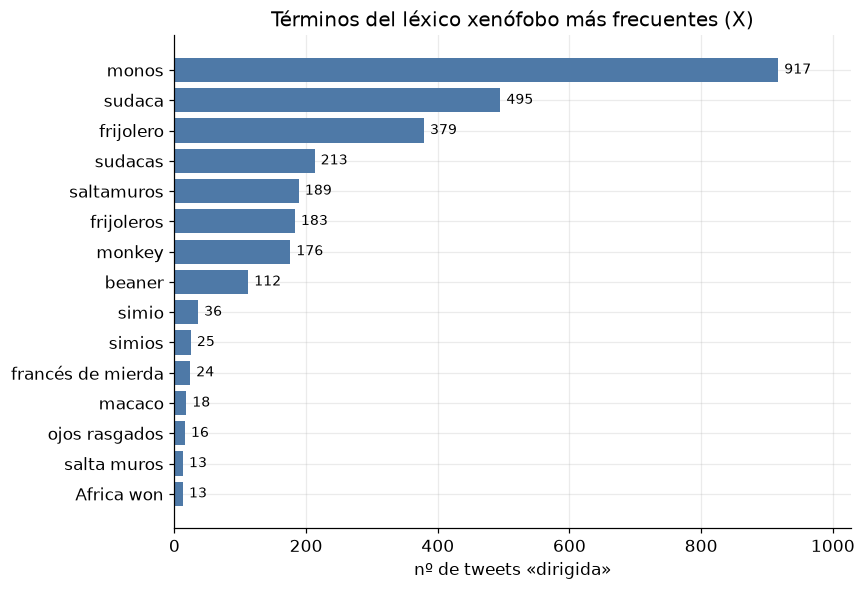

In [7]:
top = tab.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["término"], top["tweets"], color=AZUL)
for y, v in enumerate(top["tweets"]):
    ax.text(v + max(top["tweets"]) * 0.01, y, str(v), va="center", fontsize=9)
ax.set_title("Términos del léxico xenófobo más frecuentes (X)")
ax.set_xlabel("nº de tweets «dirigida»")
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

### ¿Cómo se expresa el odio? (palabra / emoji / leet / frase)

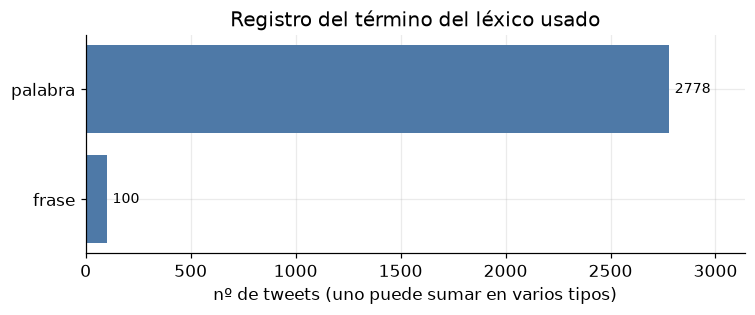

,tweets
palabra,2778
frase,100


In [8]:
EMOJI = re.compile("[\U0001F000-\U0001FAFF\u2600-\u27BF\u2B00-\u2BFF\U0001F1E6-\U0001F1FF]")

def tipo_termino(t):
    if EMOJI.search(t):
        return "emoji"
    if any(c.isdigit() for c in t) or any(c in "@*!" for c in t) or re.search(r"\.\w", t):
        return "leet / ofuscado"
    if " " in t.strip():
        return "frase"
    return "palabra"

por_tipo = Counter()
for terms in df["terminos"]:
    for t in terms:
        por_tipo[tipo_termino(t)] += 1
serie_tipo = pd.Series(por_tipo).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(serie_tipo.index, serie_tipo.values, color=AZUL)
for y, v in enumerate(serie_tipo.values):
    ax.text(v + max(serie_tipo.values) * 0.01, y, str(v), va="center", fontsize=9)
ax.set_title("Registro del término del léxico usado")
ax.set_xlabel("nº de tweets (uno puede sumar en varios tipos)")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()
serie_tipo[::-1].to_frame("tweets")

## 5. Ejes del odio: ¿qué *tipo* de xenofobia domina?

En X **recolectamos a propósito** los distintos ejes (preset `--otros-ejes`), así que
aquí se ve el balance temático que la búsqueda dirigida logró cubrir.

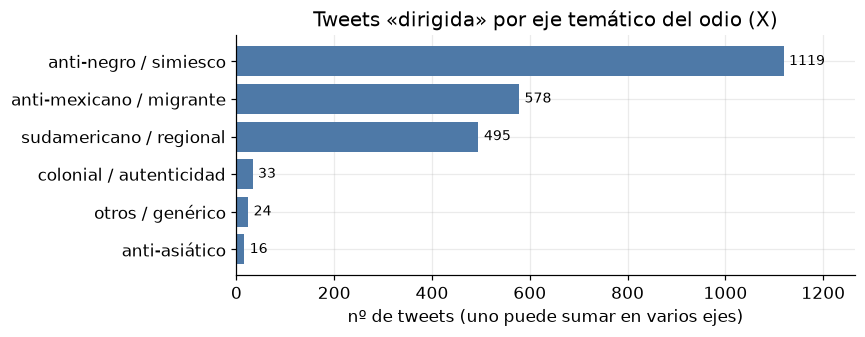

,tweets
anti-negro / simiesco,1119
anti-mexicano / migrante,578
sudamericano / regional,495
colonial / autenticidad,33
otros / genérico,24
anti-asiático,16


In [9]:
eje_counts = Counter()
for ejes in df["ejes"]:
    eje_counts.update(ejes)
serie_eje = pd.Series(eje_counts).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(serie_eje.index, serie_eje.values, color=AZUL)
for y, v in enumerate(serie_eje.values):
    ax.text(v + max(serie_eje.values) * 0.01, y, str(v), va="center", fontsize=9)
ax.set_title("Tweets «dirigida» por eje temático del odio (X)")
ax.set_xlabel("nº de tweets (uno puede sumar en varios ejes)")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()
serie_eje[::-1].to_frame("tweets")

## 6. Concentración por query (la búsqueda dirigida en acción)

Cada `criterio_busqueda` es una consulta que lanzamos a X. Muestra qué patrones
rindieron más — el equivalente al "evento gatillo" de YouTube, pero elegido por
nosotros.

In [10]:
por_q = (df.groupby("criterio_busqueda")
         .agg(tweets=("id", "count"), dirigida=("dirigida", "sum"))
         .sort_values("tweets", ascending=False))
por_q.head(15)

,tweets,dirigida
criterio_busqueda,,
France is not Africa,200,200
frijoleros,200,200
Mexico frijolero,200,200
sudacas,200,200
no son franceses de verdad,200,200
francés de mierda,200,200
Ecuador sudaca,199,199
Mexico saltamuros,186,186
Africa won the World Cup,117,117


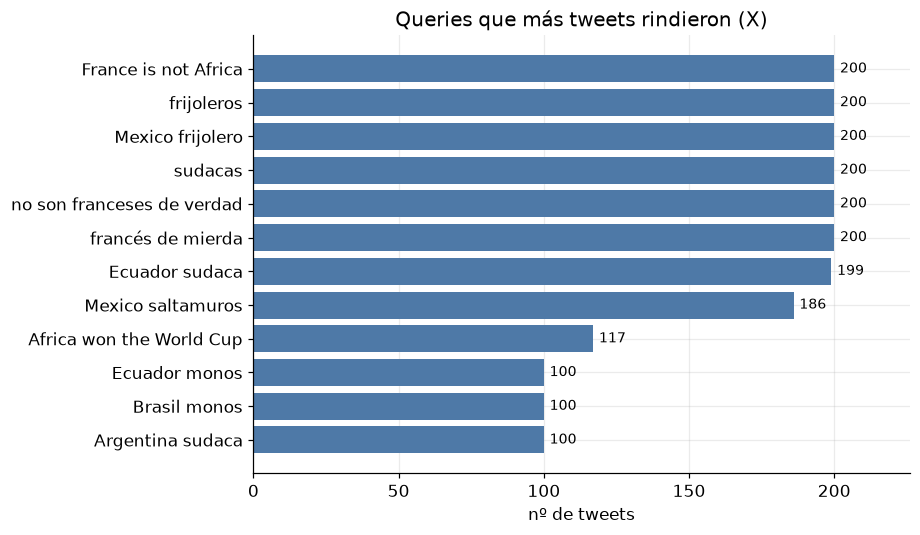

In [11]:
tq = por_q.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(tq.index, tq["tweets"], color=AZUL)
for y, v in enumerate(tq["tweets"]):
    ax.text(v + max(tq["tweets"]) * 0.01, y, str(int(v)), va="center", fontsize=9)
ax.set_title("Queries que más tweets rindieron (X)")
ax.set_xlabel("nº de tweets")
ax.margins(x=0.13)
plt.tight_layout()
plt.show()

## 7. Amplificación: likes y reposts (X como amplificador)

Uno de los ganchos del proyecto es **X como amplificador** del odio. El `repost` es
justamente el mecanismo de amplificación: mide cuánto se **redistribuye** un tweet.

In [12]:
etiqueta = df["dirigida"].map({True: "dirigida", False: "amplia"})
eng = df.groupby(etiqueta)[["likes", "reposts", "respuestas"]].agg(["mean", "median", "max"])
eng

likes                   reposts               respuestas  \
                mean median     max       mean median    max       mean   
dirigida                                                                  
amplia      0.630252    0.0      58   0.092437    0.0      6   0.159664   
dirigida  606.596173    2.0  122403  48.855823    0.0  25995  13.040581   

                       
         median   max  
dirigida               
amplia      0.0    16  
dirigida    0.0  7514

In [13]:
# Reparto de la amplificación dentro de la capa 'dirigida'.
dg = df[df["dirigida"]]
print(f"tweets dirigida: {len(dg):,}")
print(f"  con ≥1 repost:   {(dg['reposts'] > 0).sum():,} ({100*(dg['reposts']>0).mean():.1f}%)")
print(f"  con ≥1 like:     {(dg['likes'] > 0).sum():,} ({100*(dg['likes']>0).mean():.1f}%)")
print(f"  reposts totales: {int(dg['reposts'].sum()):,}  |  likes totales: {int(dg['likes'].sum()):,}")

tweets dirigida: 3,031
  con ≥1 repost:   730 (24.1%)
  con ≥1 like:     1,912 (63.1%)
  reposts totales: 148,082  |  likes totales: 1,838,593


## 8. Calidad del marcado: falsos positivos

Mismo control que en YouTube: el substring conserva a propósito `monos`⊂*vámonos* y
`simio`⊂*Simeone* para no perder portmanteaus. Medimos el ruido residual.

In [15]:
_low = df["texto"].astype(str).str.lower()
_terms_low = [e.termino.lower() for e in LEX.entradas]
substring_puro = _low.apply(lambda t: any(x in t for x in _terms_low))
n_puro, n_actual = int(substring_puro.sum()), int(df["con_lexico"].sum())
print(f"con término, substring puro:                 {n_puro}")
print(f"con término, marcado vigente (exacto + sin @): {n_actual}")
print(f"  → la corrección descartó {n_puro - n_actual} de puro ruido\n")

MONOS_FP = re.compile(
    r"\b(v[aá]monos|qued[eé]monos|imagin[eé]monos|ri[aá]monos|vay[aá]monos|"
    r"dig[aá]monos|hag[aá]monos|ve[aá]monos|pong[aá]monos|olvid[eé]monos|"
    r"sent[eé]monos|largu[eé]monos|call[eé]monos)\b",
    re.I,
)

def es_fp(term, texto):
    t = str(texto).lower()
    if term == "monos":
        tiene_slur = bool(re.search(r"\bmonos?\b", t)) or "meximonos" in t
        return bool(MONOS_FP.search(t)) and not tiene_slur
    if term == "simio":
        return ("simione" in t or "simeone" in t) and "simios" not in t and t.count("simio") <= 1
    return False

dgc = df[df["con_lexico"]].copy()
dgc["ruido"] = dgc.apply(lambda r: all(es_fp(term, r["texto"]) for term in r["terminos"]), axis=1)
n, ruido = len(dgc), int(dgc["ruido"].sum())
print(f"tweets con término del léxico: {n}")
print(f"  ruido residual (todos sus términos FP): {ruido}")
print(f"  PRECISIÓN a nivel tweet:                {100 * (n - ruido) / n:.1f}%")

con término, substring puro:                 2204
con término, marcado vigente (exacto + sin @): 2203
  → la corrección descartó 1 de puro ruido

tweets con término del léxico: 2203
  ruido residual (todos sus términos FP): 0
  PRECISIÓN a nivel tweet:                100.0%


## 9. Muestras de tweets «dirigida»

In [16]:
print("=== Top por LIKES ===")
display(df[df["con_lexico"]]
        .sort_values("likes", ascending=False)[["texto", "terminos", "idioma", "likes", "reposts"]]
        .head(10).reset_index(drop=True))

=== Top por LIKES ===


,texto,terminos,idioma,likes,reposts
0,I'M GLAD THAT BRAZIL'S MONKEYS LOST FOR MOCKING JAPAN WITH VIDEOS OF THE ATOMIC BOMBS....,[monkey],en,8865,380
1,"I don't understand. They always told us:\n\n""We're not Latinos""\n""We're not Latin Amer...",[monkey],en,6950,490
2,Literalmente vimos maltrato animal en vivo. Igual medio que en Marruecos generalmente ...,[monos],es,3302,23
3,Jajajaja los ponían como literales monos.\n\nStay classy Japan.,[monos],es,2374,37
4,"Despues de tantos años diciendonos saltamuros en debates de futbol, en el partido mas ...","[simio, simios, saltamuros, sudaca, sudacas]",es,2200,208
5,Dos Monosさんのアルバム「Dos Moons」がMUSIC AWARDS JAPAN 2026 で新設される「最優秀アートワーク賞 in association w...,[monos],ja,1624,197
6,"-“They’re blacks, hordes and hordes of blacks running after a ball”\n+”They’re French,...",[monkey],en,1536,149
7,"Por culpa del intruso que se metió al recinto de los monos en Japón, ahora seremos pri...",[monos],es,1489,82
8,anoche me quisieron afanar 3 monos encapuchados a las 5 de la mañana y descubri que pu...,[monos],es,1209,58
9,"¿Firman un Emelec campeón Copa Ecuador, Liga de Quito campeón de Libertadores e Indepe...",[sudaca],es,893,59


In [17]:
print("=== Top por REPOSTS (amplificación) ===")
display(df[df["con_lexico"]]
        .sort_values("reposts", ascending=False)[["texto", "terminos", "idioma", "reposts", "likes"]]
        .head(10).reset_index(drop=True))

=== Top por REPOSTS (amplificación) ===


,texto,terminos,idioma,reposts,likes
0,"I don't understand. They always told us:\n\n""We're not Latinos""\n""We're not Latin Amer...",[monkey],en,490,6950
1,I'M GLAD THAT BRAZIL'S MONKEYS LOST FOR MOCKING JAPAN WITH VIDEOS OF THE ATOMIC BOMBS....,[monkey],en,380,8865
2,"TOTAL CHAOS IN FRANCE\n\nMoroccans ""celebrating"" Morocco's victory over Canada in the ...",[monkey],en,353,543
3,El racismo supremacista del sionismo en palabras del hasta ahora portavoz de B. Netany...,[monos],es,263,301
4,"Despues de tantos años diciendonos saltamuros en debates de futbol, en el partido mas ...","[simio, simios, saltamuros, sudaca, sudacas]",es,208,2200
5,Dos Monosさんのアルバム「Dos Moons」がMUSIC AWARDS JAPAN 2026 で新設される「最優秀アートワーク賞 in association w...,[monos],ja,197,1624
6,"-“They’re blacks, hordes and hordes of blacks running after a ball”\n+”They’re French,...",[monkey],en,149,1536
7,"Eric García: “El árbitro me ha dicho que la toco y por eso no es fuera de juego, que d...",[monos],es,146,405
8,Jane Goodall pide a Air France no transportar monos destinados a laboratorios \nhttp:...,[monos],es,131,86
9,"UNA MINISTRA QUE NO MIRA, NO ESCUCHA Y NO QUIERE HABLAR\n\nLos tres monos sabios const...",[monos],es,124,215


## Hallazgos

> Corpus de X (recolección dirigida, 14-jul-2026): **3,150 tweets** — **3,031
> recolectados por búsqueda dirigida** + 119 por hashtags. **~2,7k autores**, en varios
> idiomas. Léxico v2 compartido con el extractor.

- **La estrategia dirigida rinde muchísimo.** De los 3,031 recolectados, **2,203 traen
  el término del léxico literal en el texto** (73 %; el resto matchearon la query por
  hilo/contexto). Esos 2,203 confirmados son **~2.7× toda la capa `dirigida` de YouTube
  (807)**, en minutos y con ~20 queries. Buscar el patrón exacto (`Brasil monos`,
  `sudacas`) va directo a la aguja; en YouTube el mismo registro era 0.2 % del pajar.

- **Cobertura multi-eje lograda a propósito.** Con el preset `--otros-ejes` recolectamos
  los cinco ejes; por **texto** dominan anti-negro/simiesco, anti-mexicano (frijolero/
  muro) y sudamericano (sudaca/argie). **Matiz clave:** el eje **colonial** se recolectó
  fuerte (~700 tweets desde queries como «France is not Africa») pero marca poco por
  substring (~33), porque es un odio **discursivo** («no son franceses de verdad»), no un
  slur único → el substring no lo ve. Es justo el tipo de registro codificado que la
  Práctica 7 debe capturar con un modelo. X complementa a YouTube en variedad temática.

- **El odio es multiidioma.** Español (~2k) e inglés (~1k) dominan, con francés,
  portugués, japonés y árabe en la cola. Es un conflicto interétnico **multi-frente y
  multilengua**, no un solo Norte→Sur — refuerza el gancho de *traducción automática de
  X como amplificador*.

- **Amplificación medible (gancho de X).** El `repost` cuantifica la redistribución del
  odio, algo que YouTube no expone. Ver arriba el reparto de reposts/likes en la capa
  `dirigida` y los tweets más amplificados.

- **Marcado consistente con YouTube y más limpio.** Mismo código de léxico, misma
  corrección de falsos positivos (límite de palabra + descarte de `@usuario`). Sobre los
  2,203 tweets con término, la **precisión es ~100 %** (casi sin el ruido `monos`⊂*vámonos*
  / `simio`⊂*Simeone* que sí aparecía en YouTube): en X la gente escribe el insulto
  directo, no incrustado en palabras inocentes.

**Conclusión:** X aporta un corpus `dirigida` **denso, multilingüe y multi-eje** que
equilibra al de YouTube (amplio y con la aguja diluida). Igual que allá, `dirigida`
sigue siendo un **filtro de recall alto para pre-etiquetar** (no etiqueta final): la
revisión y el modelado fino son tarea de la Práctica 7.